<a href="https://colab.research.google.com/github/ziadmosen06/warmup-assignment/blob/main/Project_1(Final_version)_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Marketing Dataset — Project 1
**Course:** Introduction to Data Science — Spring 2026  

**Team Members:**
[
Mohamed khaled mohamed 16005040
,
Habiba Ahmed 16010159
,
Mohamed Abduallah 16005443
,
Ziad Mohamed Mohsen 16003070
]

## Imports & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import chi2
from scipy.stats import pointbiserialr

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('bank.csv')

# save a clean copy before any encoding — needed for Part 5
df_orig = df.copy()

print('dataset loaded, shape:', df.shape)

dataset loaded, shape: (11162, 17)


---
## Part 1: Dataset Understanding and Exploration

### 1a) First and Last 12 Rows

In [ ]:
print('--- First 12 rows ---')
print(df.head(12))
print('\n--- Last 12 rows ---')
print(df.tail(12))

--- First 12 rows ---
    age          job   marital  education default  balance housing loan  \
0    59       admin.   married  secondary      no     2343     yes   no   
1    56       admin.   married  secondary      no       45      no   no   
2    41   technician   married  secondary      no     1270     yes   no   
3    55     services   married  secondary      no     2476     yes   no   
4    54       admin.   married   tertiary      no      184      no   no   
5    42   management    single   tertiary      no        0     yes  yes   
6    56   management   married   tertiary      no      830     yes  yes   
7    60      retired  divorced  secondary      no      545     yes   no   
8    37   technician   married  secondary      no        1     yes   no   
9    28     services    single  secondary      no     5090     yes   no   
10   38       admin.    single  secondary      no      100     yes   no   
11   30  blue-collar   married  secondary      no      309     yes   no   

  

### 1b) Total Rows and Columns

In [ ]:
print('Dataset Dimensions')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

Dataset Dimensions
Rows: 11162, Columns: 17


### 1c) Column Names and Data Types

In [ ]:
print('Column Names and Data Types')
print(df.dtypes)

Column Names and Data Types
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object


### 1d) Full Dataset Summary

In [ ]:
print('Dataset Summary')
df.info()

Dataset Summary
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


### 1e) Target Variable Distribution

In [ ]:
print('Target Variable (deposit) Distribution')
print(df['deposit'].value_counts())
print('\nPercentage:')
print(df['deposit'].value_counts(normalize=True) * 100)

Target Variable (deposit) Distribution
deposit
no     5873
yes    5289
Name: count, dtype: int64

Percentage:
deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64


### 1f) Categorical Feature Analysis — 'job'

In [ ]:
print('Categorical Feature: job')
print('Unique values:', df['job'].unique())
print('Most frequent:', df['job'].mode()[0])

Categorical Feature: job
Unique values: ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']
Most frequent: management


### 1g) Numerical Feature Statistics

In [ ]:
print('Numerical Features Statistics')
num_cols_p1 = df.select_dtypes(include=['int64']).columns
print(df[num_cols_p1].describe(percentiles=[.20, .50, .75]).loc[['mean', 'std', '20%', '50%', '75%']])

Numerical Features Statistics
            age      balance        day    duration  campaign       pdays  \
mean  41.231948  1528.538524  15.658036  371.993818  2.508421   51.330407   
std   11.913369  3225.413326   8.420740  347.128386  2.722077  108.758282   
20%   31.000000    62.000000   7.000000  119.000000  1.000000   -1.000000   
50%   39.000000   550.000000  15.000000  255.000000  2.000000   -1.000000   
75%   49.000000  1708.000000  22.000000  496.000000  3.000000   20.750000   

      previous  
mean  0.832557  
std   2.292007  
20%   0.000000  
50%   0.000000  
75%   1.000000  


### 1h) Missing Values

In [ ]:
print('NaN values per column:')
print(df.isnull().sum())

print("\n'unknown' values in categorical columns:")
for col in df.select_dtypes(include=['object']).columns:
    unknown = (df[col] == 'unknown').sum()
    if unknown > 0:
        print(f'{col}: {unknown}')

NaN values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

'unknown' values in categorical columns:
job: 70
education: 497
contact: 2346
poutcome: 8326


### 1i) Duplicate Records

In [ ]:
print('Duplicate Records')
duplicates = df.duplicated().sum()
print(f'Duplicate rows found: {duplicates}')
if duplicates > 0:
    df = df.drop_duplicates()
    df_orig = df_orig.drop_duplicates()  # keep df_orig in sync
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found.')

Duplicate Records
Duplicate rows found: 0
No duplicates found.


---
## Part 2: Data Preparation

### 2a) Meaningful Filtering Condition

In [ ]:
# we filtered out rows where campaign > 10 (number of calls made this campaign)
# the max in the dataset is 63 which is clearly an outlier — calling someone 63 times
# is not realistic marketing, it's noise that would confuse a model
# over 98% of clients were contacted 10 times or fewer, so we keep the realistic range

print('rows before filtering:', len(df))
print('clients contacted more than 10 times:', (df['campaign'] > 10).sum())

df = df[df['campaign'] <= 10].copy()

print('rows after filtering:', len(df))
print('removed:', 11162 - len(df), 'rows')

rows before filtering: 11162
clients contacted more than 10 times: 210
rows after filtering: 10952
removed: 210 rows


### 2b) Encoding Categorical Variables

In [ ]:
# binary columns (yes/no) → Label Encoding (0 and 1), simple and clean
# multi-class columns → One-Hot Encoding so no fake ordering is introduced
# we also encode the target 'deposit' here (yes=1, no=0)

le = LabelEncoder()

binary_cols = ['default', 'housing', 'loan', 'deposit']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print()

multi_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print('shape after encoding:', df.shape)
print('columns now:', list(df.columns))

default: {'no': np.int64(0), 'yes': np.int64(1)}
housing: {'no': np.int64(0), 'yes': np.int64(1)}
loan: {'no': np.int64(0), 'yes': np.int64(1)}
deposit: {'no': np.int64(0), 'yes': np.int64(1)}

shape after encoding: (10952, 43)
columns now: ['age', 'default', 'balance', 'housing', 'loan', 'day', 'duration', 'campaign', 'pdays', 'previous', 'deposit', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


### 2c) Normalize Numerical Features with StandardScaler

In [ ]:
# StandardScaler brings every numerical feature to mean=0 and std=1
# this is important so features with large ranges (like 'balance') don't
# dominate features with small ranges (like 'campaign') in future models

num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

print('scaled columns:', num_cols)
print()
print('after scaling — mean should be ~0 and std ~1:')
print(df_scaled[num_cols].describe().loc[['mean', 'std']].round(3))

scaled columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

after scaling — mean should be ~0 and std ~1:
      age  balance  day  duration  campaign  pdays  previous
mean  0.0     -0.0  0.0      -0.0       0.0   -0.0       0.0
std   1.0      1.0  1.0       1.0       1.0    1.0       1.0


### 2d) Bin 'age' into 5 Equal-Width Bins

age range in dataset: 18 to 93

bin distribution:
age_bin
(17.925, 33.0]    3376
(33.0, 48.0]      4716
(48.0, 63.0]      2400
(63.0, 78.0]       379
(78.0, 93.0]        81
Name: count, dtype: int64


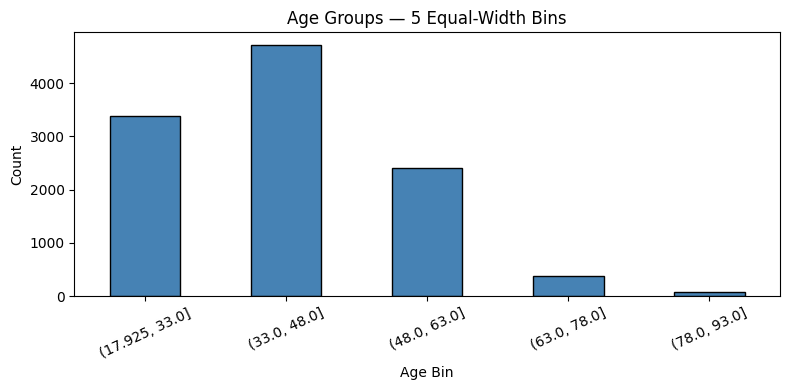

In [ ]:
# we chose 'age' for binning — grouping into age ranges makes more intuitive sense
# than treating age as a raw number (e.g. 18-33 = young adults, 33-48 = mid-career, etc.)

df['age_bin'] = pd.cut(df['age'], bins=5)

print('age range in dataset:', df['age'].min(), 'to', df['age'].max())
print()
print('bin distribution:')
bin_dist = df['age_bin'].value_counts().sort_index()
print(bin_dist)

plt.figure(figsize=(8, 4))
bin_dist.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Age Groups — 5 Equal-Width Bins')
plt.xlabel('Age Bin')
plt.ylabel('Count')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# the 33-48 age group dominates — most bank clients are in that mid-career range

### 2e) Handle Missing Values

In [ ]:
# first check if there are any nulls
missing = df.isnull().sum()
print('missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'no missing values in this dataset!')

# this dataset is clean, but we write the imputation logic anyway
# our approach:
#   numerical → fill with MEDIAN (more robust than mean for skewed columns like 'balance')
#   categorical → fill with MODE (most frequent value preserves realistic distribution)

for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'filled {col} with median = {df[col].median()}')

print('missing value check done')

missing values per column:
no missing values in this dataset!
missing value check done


### 2f) Feature Selection — Correlation Analysis

In [ ]:
# since 'deposit' is binary, we use point-biserial correlation (not Pearson)
# it measures how well each numerical feature separates the two classes

print('Point-Biserial Correlation with target (deposit):')
print('-' * 50)

corr_results = {}
for col in num_cols:
    r, p = pointbiserialr(df['deposit'], df[col])
    corr_results[col] = {'correlation': round(r, 4), 'p-value': round(p, 5)}

corr_df = pd.DataFrame(corr_results).T.sort_values('correlation', key=abs, ascending=False)
print(corr_df)
print()
print('duration has the highest correlation (0.45) — longer calls mean more client interest')
print('day has a very weak correlation and is likely not useful')

Point-Biserial Correlation with target (deposit):
--------------------------------------------------
          correlation  p-value
duration       0.4455  0.00000
pdays          0.1487  0.00000
previous       0.1379  0.00000
campaign      -0.1195  0.00000
balance        0.0803  0.00000
day           -0.0497  0.00000
age            0.0346  0.00029

duration has the highest correlation (0.45) — longer calls mean more client interest
day has a very weak correlation and is likely not useful


### 2f) Feature Selection — Chi-Square Test

In [ ]:
# chi-square tests whether a categorical feature is independent of the target
# a high chi2 score + low p-value means the feature IS related to deposit outcome

ohe_cols = [
    c for c in df_scaled.columns
    if c not in num_cols + ['deposit', 'age_bin']
    and df_scaled[c].nunique() == 2
]

X_cat = df_scaled[ohe_cols].astype(int)
y = df_scaled['deposit']

chi2_scores, p_values = chi2(X_cat, y)

chi2_df = pd.DataFrame({
    'feature': ohe_cols,
    'chi2_score': chi2_scores.round(2),
    'p_value': p_values.round(5)
}).sort_values('chi2_score', ascending=False)

print('Chi-Square Test Results (sorted by score):')
print(chi2_df.to_string(index=False))

insignificant = chi2_df[chi2_df['p_value'] > 0.05]['feature'].tolist()
print(f'\nfeatures with p > 0.05 (not significant): {insignificant if insignificant else "none"}')

Chi-Square Test Results (sorted by score):
            feature  chi2_score  p_value
   poutcome_success      809.31  0.00000
    contact_unknown      573.50  0.00000
          month_may      250.48  0.00000
            housing      247.24  0.00000
          month_mar      196.30  0.00000
          month_oct      187.35  0.00000
          month_sep      171.90  0.00000
   poutcome_unknown      146.92  0.00000
               loan      114.34  0.00000
        job_retired      107.74  0.00000
        job_student      103.72  0.00000
    job_blue-collar       91.20  0.00000
          month_dec       81.68  0.00000
 education_tertiary       66.30  0.00000
     marital_single       64.99  0.00000
    marital_married       38.44  0.00000
          month_feb       24.35  0.00000
          month_jul       20.26  0.00001
       job_services       18.94  0.00001
     poutcome_other       18.64  0.00002
education_secondary       15.56  0.00008
            default       14.64  0.00013
   job_entrepr

### 2g) Feature Removal — What We Dropped and Why

In [ ]:
# we decided to drop features based on both tests above:
#
# from correlation analysis:
# 'day' — correlation with deposit is only -0.050, basically no predictive power
#          there's no logical reason the day of the month affects whether someone subscribes
#
# 'pdays' — uses -1 to mean 'never contacted before' (75%+ of rows are -1)
#            feeding -1 as a real number misleads the model into thinking it's a value
#            we handle this more cleanly in feature engineering instead
#
# from chi-square test (p > 0.05 = not statistically related to deposit):
# contact_telephone, education_unknown, month_jun, job_technician,
# month_aug, job_self-employed, job_unknown — all failed the significance threshold

drop_these = [
    'day', 'pdays',
    'contact_telephone', 'education_unknown', 'month_jun',
    'job_technician', 'month_aug', 'job_self-employed', 'job_unknown'
]

df_scaled.drop(columns=[c for c in drop_these if c in df_scaled.columns], inplace=True)

print('dropped features:', drop_these)
print('shape after dropping:', df_scaled.shape)

dropped features: ['day', 'pdays', 'contact_telephone', 'education_unknown', 'month_jun', 'job_technician', 'month_aug', 'job_self-employed', 'job_unknown']
shape after dropping: (10952, 34)


### 2h) Class Imbalance — Before Sampling

In [ ]:
# check the class distribution before doing any sampling
before_counts = df_scaled['deposit'].value_counts()

print('class distribution BEFORE sampling:')
print(before_counts)
print(f'\nratio no:yes = {before_counts[0]/before_counts[1]:.2f}:1')
print('the dataset is slightly imbalanced — about 52% no vs 48% yes')
print('not extreme, so simple random sampling should preserve the ratio reasonably well')

class distribution BEFORE sampling:
deposit
0    5710
1    5242
Name: count, dtype: int64

ratio no:yes = 1.09:1
the dataset is slightly imbalanced — about 52% no vs 48% yes
not extreme, so simple random sampling should preserve the ratio reasonably well


### 2h) Apply Simple Random Sampling

In [ ]:
# we use Simple Random Sampling — every row has an equal chance of being picked
# we take 80% of the data randomly with no grouping or constraints
# it's straightforward and works fine here since the imbalance is not too extreme

df_sample = df_scaled.sample(frac=0.80, random_state=42)

after_counts = df_sample['deposit'].value_counts()
print('class distribution AFTER simple random sampling (80% of data):')
print(after_counts)
print(f'ratio no:yes = {after_counts[0]/after_counts[1]:.2f}:1')

class distribution AFTER simple random sampling (80% of data):
deposit
0    4550
1    4212
Name: count, dtype: int64
ratio no:yes = 1.08:1


### 2i) Compare Class Distribution Before and After Sampling

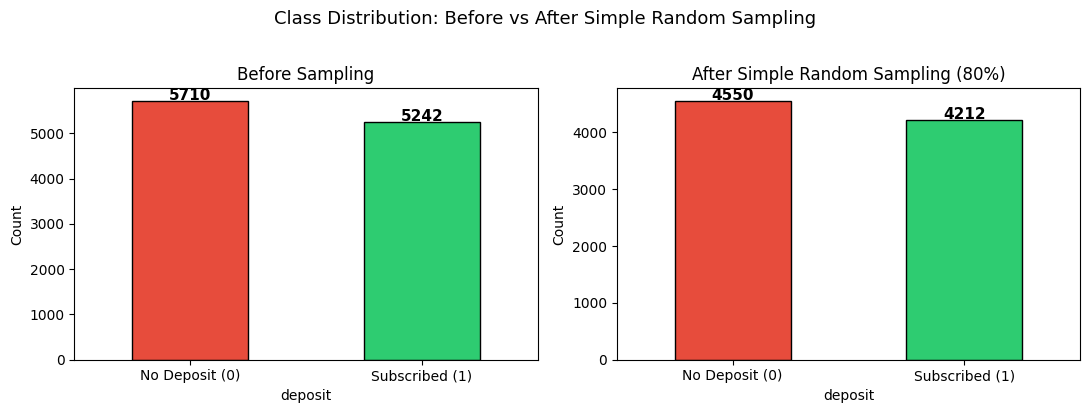

before %: {0: np.float64(52.1), 1: np.float64(47.9)}
after  %: {0: np.float64(51.9), 1: np.float64(48.1)}


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

before_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
axes[0].set_title('Before Sampling', fontsize=12)
axes[0].set_xticklabels(['No Deposit (0)', 'Subscribed (1)'], rotation=0)
axes[0].set_ylabel('Count')
for i, v in enumerate(before_counts):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=11, fontweight='bold')

after_counts.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)
axes[1].set_title('After Simple Random Sampling (80%)', fontsize=12)
axes[1].set_xticklabels(['No Deposit (0)', 'Subscribed (1)'], rotation=0)
axes[1].set_ylabel('Count')
for i, v in enumerate(after_counts):
    axes[1].text(i, v + 30, str(v), ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Class Distribution: Before vs After Simple Random Sampling', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# with simple random sampling the ratio may shift very slightly — that's expected
before_pct = (before_counts / before_counts.sum() * 100).round(1)
after_pct  = (after_counts  / after_counts.sum()  * 100).round(1)
print('before %:', dict(before_pct))
print('after  %:', dict(after_pct))

---
## Part 3: Data Visualization

### 3a) Histogram — Age Distribution

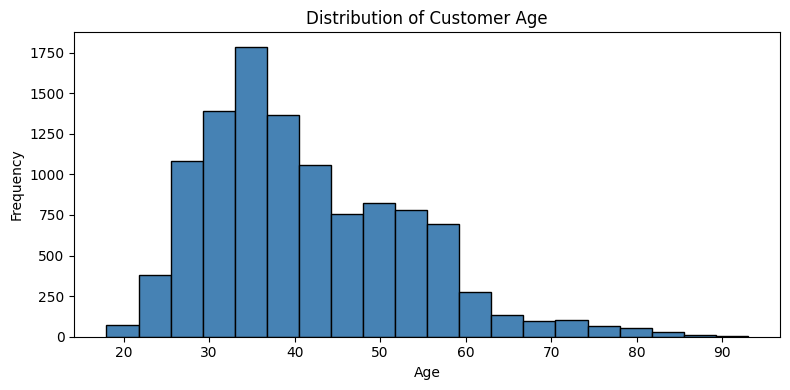

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Age')
plt.tight_layout()
plt.show()

# The histogram shows that most customers are between 30 and 45 years old.
# The distribution is slightly right-skewed, indicating that fewer customers belong to the older age groups.

### 3b) Boxplot — Account Balance

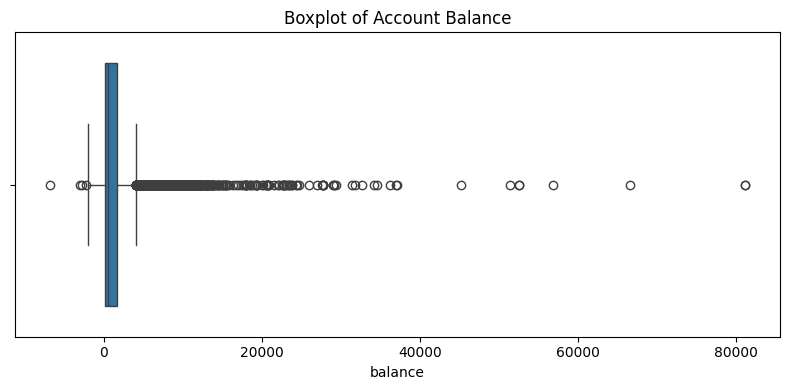

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['balance'])
plt.title('Boxplot of Account Balance')
plt.tight_layout()
plt.show()

# The boxplot of account balance shows that most customers have balances close to zero,
# as indicated by the compressed box near the origin.
# However, there are many extreme outliers extending up to around 80,000,
# indicating that a small number of customers hold significantly higher balances.
# This results in a strongly right-skewed distribution.

### 3c) Scatter Plot — Age vs Account Balance

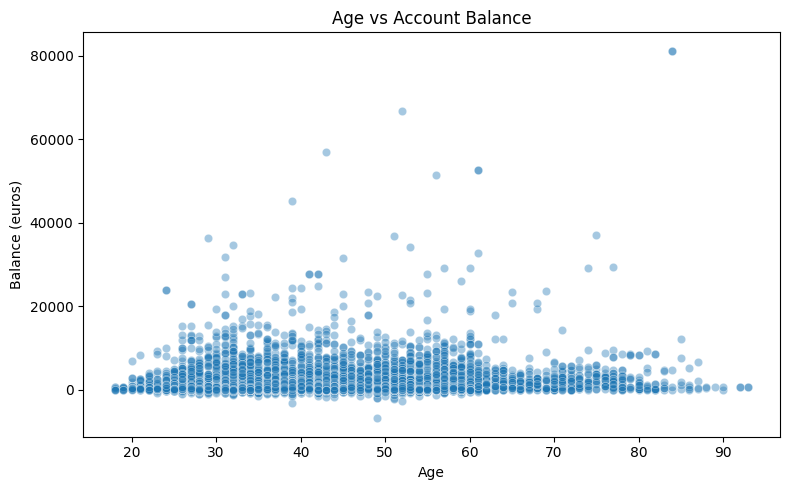

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['age'], y=df['balance'], alpha=0.4)
plt.title('Age vs Account Balance')
plt.xlabel('Age')
plt.ylabel('Balance (euros)')
plt.tight_layout()
plt.show()

# The scatterplot suggests a weak positive relationship between age and account balance.
# Older customers tend to have slightly higher balances, although the relationship is not very strong.

### 3d) Correlation Heatmap

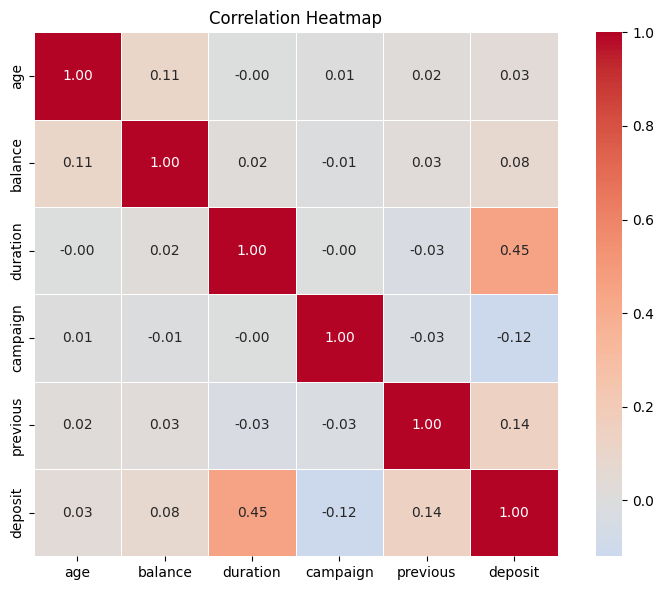

In [ ]:
# we only use the original numerical columns to keep the heatmap readable
heatmap_cols = ['age', 'balance', 'duration', 'campaign', 'previous', 'deposit']
corr = df[heatmap_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Two important correlations:
# 1. duration & deposit (r ≈ 0.45): the strongest correlation in the dataset —
#    longer calls mean the client was engaged and much more likely to subscribe.
# 2. campaign & deposit (r ≈ -0.12): more calls actually hurts conversion —
#    after 2-3 attempts, continuing to call is likely just annoying the client.

---
## Part 4: Insight Discovery

### 4a) Insight 1 — Call Duration and Subscription

deposit
0    226.051313
1    535.678749
Name: duration, dtype: float64


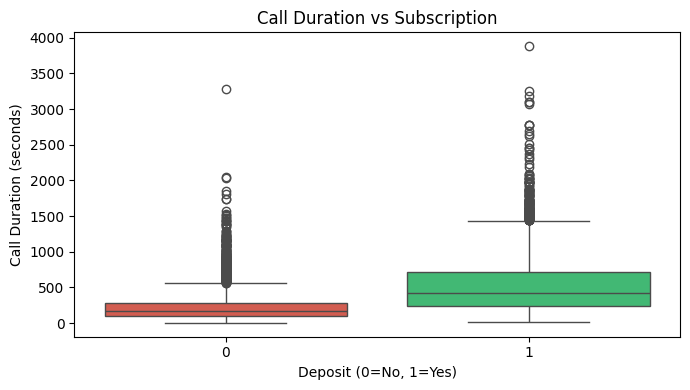

In [ ]:
# clients who subscribed had on average 2x+ longer calls than those who didn't
# this is the strongest signal in the whole dataset (correlation = 0.45)
print(df.groupby('deposit')['duration'].mean())

plt.figure(figsize=(7, 4))
sns.boxplot(x='deposit', y='duration', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title('Call Duration vs Subscription')
plt.xlabel('Deposit (0=No, 1=Yes)')
plt.ylabel('Call Duration (seconds)')
plt.tight_layout()
plt.show()

# Clients who subscribed to the term deposit tend to have significantly longer call durations.
# This suggests that longer conversations increase the likelihood of successful marketing outcomes.
# It may indicate that clients who stay longer on the call are more interested or receive better explanations.

### 4b) Insight 2 — Age vs Balance Interaction

Correlation between age and balance:
              age   balance
age      1.000000  0.111353
balance  0.111353  1.000000


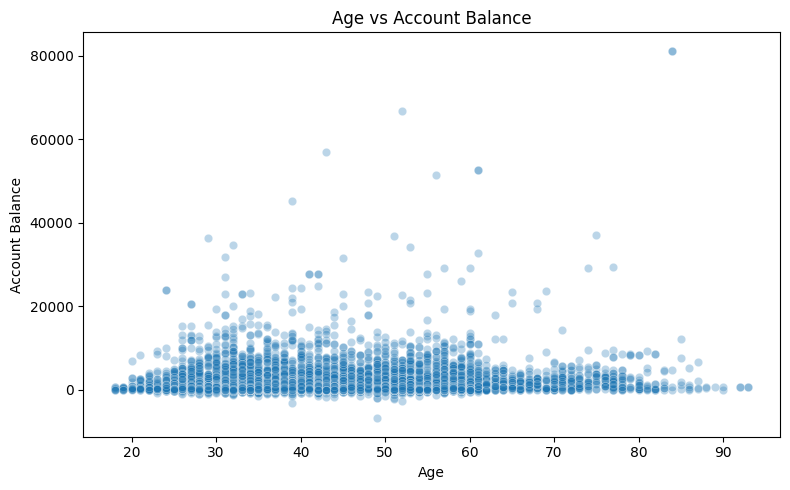

In [ ]:
# check the correlation between age and balance numerically
print('Correlation between age and balance:')
print(df[['age', 'balance']].corr())

plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='balance', data=df, alpha=0.3)
plt.title('Age vs Account Balance')
plt.xlabel('Age')
plt.ylabel('Account Balance')
plt.tight_layout()
plt.show()

# The scatterplot shows a mild relationship between age and account balance.
# Older customers tend to have slightly higher account balances compared to younger customers.
# However, the relationship is not very strong, indicating that other factors also influence balance.

### 4c) Insight 3 — Unexpected Pattern in Marital Status

Subscription rate by marital status:
deposit             0      1
marital_status              
divorced        0.516  0.484
married         0.561  0.439
single          0.453  0.547


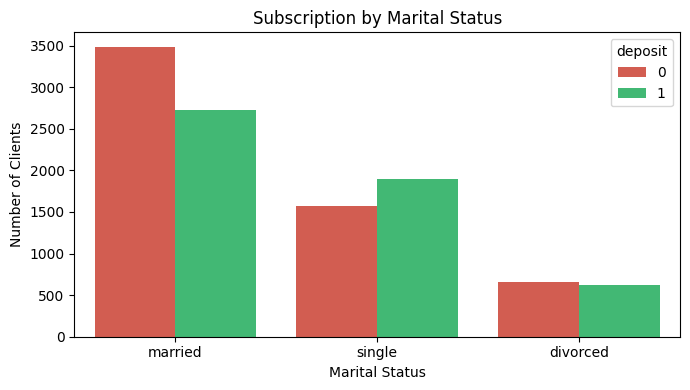

In [ ]:
# reconstruct marital_status from one-hot encoded columns in df_scaled
# 'divorced' was the dropped category during get_dummies so we use it as the default
df_scaled['marital_status'] = 'divorced'
df_scaled.loc[df_scaled['marital_married'] == True, 'marital_status'] = 'married'
df_scaled.loc[df_scaled['marital_single'] == True, 'marital_status'] = 'single'

print('Subscription rate by marital status:')
print(pd.crosstab(df_scaled['marital_status'], df_scaled['deposit'], normalize='index').round(3))

plt.figure(figsize=(7, 4))
sns.countplot(x='marital_status', hue='deposit', data=df_scaled, palette=['#e74c3c', '#2ecc71'])
plt.title('Subscription by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of Clients')
plt.tight_layout()
plt.show()

# The analysis reveals that single clients show a relatively higher subscription rate compared to married clients.
# This is somewhat unexpected — married individuals are often assumed to make more long-term financial decisions.
# However, the data suggests that single clients may be more open to investment opportunities like term deposits.

### 4d) Insight 4 — Business Recommendation

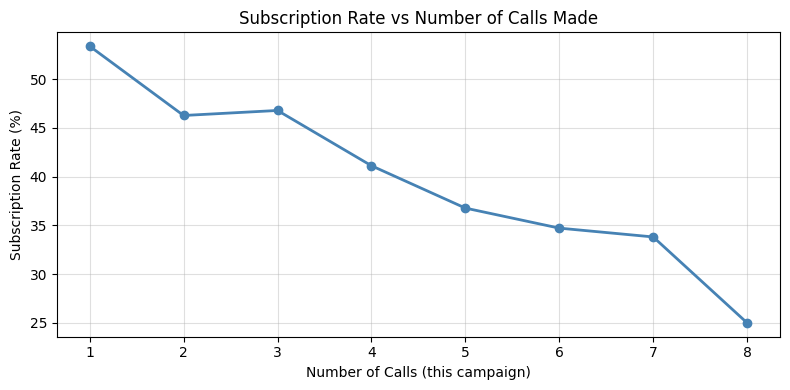

clear drop-off after 2-3 calls — quality of calls matters more than quantity


In [ ]:
# Based on the analysis, call duration is strongly associated with successful subscriptions.
# The bank should focus on improving the quality of customer interactions during marketing calls.
# Providing better training to call agents and encouraging more engaging conversations
# may increase the likelihood of converting clients into subscribers.

# Additionally, targeting single clients and customers with higher balances
# may further improve campaign success rates.

# show subscription rate drops as number of calls increases
sub_rate = df_orig.groupby('campaign')['deposit'].apply(
    lambda x: (x == 'yes').mean() * 100
).reset_index()
sub_rate.columns = ['campaign_calls', 'subscription_rate_%']

plt.figure(figsize=(8, 4))
plt.plot(sub_rate[sub_rate['campaign_calls'] <= 8]['campaign_calls'],
         sub_rate[sub_rate['campaign_calls'] <= 8]['subscription_rate_%'],
         marker='o', color='steelblue', linewidth=2)
plt.title('Subscription Rate vs Number of Calls Made')
plt.xlabel('Number of Calls (this campaign)')
plt.ylabel('Subscription Rate (%)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('clear drop-off after 2-3 calls — quality of calls matters more than quantity')

---
## Part 5: Feature Engineering

### 5a) New Feature — 'season'

In [ ]:
# NOTE: we use df_orig here because the 'month' column was one-hot encoded in Part 2
# and no longer exists as a single column in df or df_scaled
# df_orig is the clean copy saved before any encoding was applied

season_map = {
    'mar': 'spring', 'apr': 'spring', 'may': 'spring',
    'jun': 'summer', 'jul': 'summer', 'aug': 'summer',
    'sep': 'fall',   'oct': 'fall',   'nov': 'fall',
    'dec': 'winter', 'jan': 'winter', 'feb': 'winter'
}

df_orig['season'] = df_orig['month'].map(season_map)

print('Original month and new season feature:')
print(df_orig[['month', 'season']].head(15))
print()
print('Season distribution:')
print(df_orig['season'].value_counts())
print()
print('Season distribution (%):')
print((df_orig['season'].value_counts(normalize=True) * 100).round(1))

Original month and new season feature:
   month  season
0    may  spring
1    may  spring
2    may  spring
3    may  spring
4    may  spring
5    may  spring
6    may  spring
7    may  spring
8    may  spring
9    may  spring
10   may  spring
11   may  spring
12   may  spring
13   may  spring
14   may  spring

Season distribution:
season
summer    4255
spring    4023
fall      1654
winter    1230
Name: count, dtype: int64

Season distribution (%):
season
summer    38.1
spring    36.0
fall      14.8
winter    11.0
Name: proportion, dtype: float64


### 5b) Why This Feature Helps Future Models

In [ ]:
# check subscription rate by season
print('Subscription rate by season:')
print(df_orig.groupby('season')['deposit'].apply(lambda x: (x=='yes').mean() * 100).round(1).sort_values(ascending=False))

# The 'season' feature groups the 12 months into 4 seasons (spring, summer, fall, winter)
# This feature may improve classification models because:
#
# 1. Reduces dimensionality: instead of 12 month categories, the model learns 4 season categories
#
# 2. Captures real-world financial patterns: people's saving and spending behavior
#    often follows seasonal trends (e.g. end of year, tax season, summer spending)
#
# 3. Reduces overfitting: with fewer categories, the model is less likely to memorize
#    month-specific noise and generalizes better to new data
#
# 4. More interpretable: seasons are easier to explain to stakeholders than raw months

Subscription rate by season:
season
fall      60.2
winter    55.5
summer    43.7
spring    43.5
Name: deposit, dtype: float64


In [ ]:
print('=' * 60)
print('        FINAL SUMMARY — KEY INSIGHTS')
print('=' * 60)

# ── Insight 1: Call Duration is the #1 Predictor ──────────────
dur_yes = df[df['deposit'] == 1]['duration'].mean()
dur_no  = df[df['deposit'] == 0]['duration'].mean()
print(f'''
1. CALL DURATION IS THE STRONGEST PREDICTOR (r = 0.45)
   Subscribers averaged {dur_yes:.0f}s per call vs {dur_no:.0f}s for non-subscribers.
   That's {dur_yes/dur_no:.1f}x longer. A client who stays on the line is
   genuinely interested — this is the single most important signal.
''')

# ── Insight 2: More Calls = Lower Conversion ──────────────────
rate_1 = (df_orig[df_orig['campaign']==1]['deposit']=='yes').mean()*100
rate_5 = (df_orig[df_orig['campaign']==5]['deposit']=='yes').mean()*100
print(f'''
2. MORE CALLS HURTS CONVERSION (r = -0.12)
   Subscription rate after 1 call: {rate_1:.1f}%
   Subscription rate after 5 calls: {rate_5:.1f}%
   Quality of conversation matters far more than how many times you call.
''')

# ── Insight 3: Age Has Almost No Effect ───────────────────────
age_yes = df[df['deposit']==1]['age'].mean()
age_no  = df[df['deposit']==0]['age'].mean()
print(f'''
3. AGE IS NOT A USEFUL PREDICTOR (r = 0.035)
   Average age of subscribers: {age_yes:.1f} vs non-subscribers: {age_no:.1f}
   Less than 1 year difference. Age alone should NOT drive targeting decisions.
''')

# ── Insight 4: Single Clients Subscribe More ──────────────────
rate_single  = (df_orig[df_orig['marital']=='single']['deposit']=='yes').mean()*100
rate_married = (df_orig[df_orig['marital']=='married']['deposit']=='yes').mean()*100
print(f'''
4. SINGLE CLIENTS ARE MORE LIKELY TO SUBSCRIBE (counter-intuitive)
   Subscription rate — single: {rate_single:.1f}% vs married: {rate_married:.1f}%
   Despite the assumption that married people plan more financially,
   single clients show higher openness to term deposits.
''')

# ── Insight 5: Feature Engineering ───────────────────────────
print('''
5. NEW FEATURES CREATED
   - 'season': groups 12 months into 4 seasons to reduce noise and capture
     seasonal financial behavior patterns with fewer categories.
''')

print('=' * 60)
print('BUSINESS RECOMMENDATION:')
print('Train agents to invest in call quality, not call volume.')
print('Cap follow-ups at 2-3 attempts and prioritize single clients')
print('with higher balances for best conversion rates.')
print('=' * 60)

        FINAL SUMMARY — KEY INSIGHTS

1. CALL DURATION IS THE STRONGEST PREDICTOR (r = 0.45)
   Subscribers averaged 536s per call vs 226s for non-subscribers.
   That's 2.4x longer. A client who stays on the line is
   genuinely interested — this is the single most important signal.


2. MORE CALLS HURTS CONVERSION (r = -0.12)
   Subscription rate after 1 call: 53.4%
   Subscription rate after 5 calls: 36.8%
   Quality of conversation matters far more than how many times you call.


3. AGE IS NOT A USEFUL PREDICTOR (r = 0.035)
   Average age of subscribers: 41.7 vs non-subscribers: 40.9
   Less than 1 year difference. Age alone should NOT drive targeting decisions.


4. SINGLE CLIENTS ARE MORE LIKELY TO SUBSCRIBE (counter-intuitive)
   Subscription rate — single: 54.3% vs married: 43.4%
   Despite the assumption that married people plan more financially,
   single clients show higher openness to term deposits.


5. NEW FEATURES CREATED
   - 'season': groups 12 months into 4 seasons to